In [1]:
import pandas as pd
import numpy as np
import sqlite3
import pathlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Configura o caminho para o banco de dados
project_root = pathlib.Path("..") 
db_path = project_root / "banco de dados" / "crash_bot_historico.db"

print(f"Carregando dados de: {db_path}")

with sqlite3.connect(db_path) as conn:
    query = "SELECT timestamp, multiplicador FROM multiplicadores_historico ORDER BY timestamp ASC"
    df = pd.read_sql_query(query, conn, parse_dates=["timestamp"])

df = df.reset_index(drop=True)
multiplicadores = df['multiplicador'].values
print(f"✅ {len(multiplicadores):,} rodadas carregadas.")

# Identificar posições das quebras
QUEBRAS_POS = [22197, 24513, 39938, 41555, 63812, 100639]
print(f"\n💀 Quebras identificadas nas posições: {QUEBRAS_POS}")

Carregando dados de: ..\banco de dados\crash_bot_historico.db
✅ 105,281 rodadas carregadas.

💀 Quebras identificadas nas posições: [22197, 24513, 39938, 41555, 63812, 100639]


In [2]:
# --- CÉLULA 2: EXTRAIR FEATURES DETALHADAS ---

print("="*80)
print("🔬 EXTRAÇÃO DE FEATURES AVANÇADAS")
print("="*80)

def extrair_features_completas(mult, pos, janelas=[10, 20, 50, 100, 250]):
    """Extrai um conjunto completo de features para uma posição."""
    features = {'posicao': pos}
    
    for j in janelas:
        inicio = max(0, pos - j)
        janela = mult[inicio:pos]
        
        if len(janela) < j // 2:
            continue
        
        prefix = f'j{j}_'
        
        # Básicas
        features[prefix + 'pct_baixas'] = np.sum(janela < 2.0) / len(janela) * 100
        features[prefix + 'media'] = np.mean(janela)
        features[prefix + 'mediana'] = np.median(janela)
        features[prefix + 'std'] = np.std(janela)
        features[prefix + 'min'] = np.min(janela)
        features[prefix + 'max'] = np.max(janela)
        
        # Percentis
        features[prefix + 'p10'] = np.percentile(janela, 10)
        features[prefix + 'p25'] = np.percentile(janela, 25)
        features[prefix + 'p75'] = np.percentile(janela, 75)
        features[prefix + 'p90'] = np.percentile(janela, 90)
        
        # Baixas "fortes" (< 1.5x)
        features[prefix + 'pct_muito_baixas'] = np.sum(janela < 1.5) / len(janela) * 100
        
        # Altas significativas
        features[prefix + 'pct_altas_5x'] = np.sum(janela >= 5.0) / len(janela) * 100
        features[prefix + 'pct_altas_10x'] = np.sum(janela >= 10.0) / len(janela) * 100
        
        # Sequências de baixas
        seq_atual = 0
        seqs = []
        for v in janela:
            if v < 2.0:
                seq_atual += 1
            else:
                if seq_atual > 0:
                    seqs.append(seq_atual)
                seq_atual = 0
        if seq_atual > 0:
            seqs.append(seq_atual)
        
        features[prefix + 'seq_max'] = max(seqs) if seqs else 0
        features[prefix + 'seq_media'] = np.mean(seqs) if seqs else 0
        features[prefix + 'seq_count'] = len(seqs)
        features[prefix + 'seq_5plus'] = sum(1 for s in seqs if s >= 5)
        features[prefix + 'seq_4plus'] = sum(1 for s in seqs if s >= 4)
        
        # Tendência
        x = np.arange(len(janela))
        slope, intercept, r_value, p_value, std_err = stats.linregress(x, janela)
        features[prefix + 'slope'] = slope
        features[prefix + 'r_squared'] = r_value ** 2
        
        # Comparação início vs fim
        meio = len(janela) // 2
        primeira_metade = janela[:meio]
        segunda_metade = janela[meio:]
        features[prefix + 'delta_baixas'] = (np.sum(segunda_metade < 2.0) / len(segunda_metade) - 
                                              np.sum(primeira_metade < 2.0) / len(primeira_metade)) * 100
        features[prefix + 'delta_media'] = np.mean(segunda_metade) - np.mean(primeira_metade)
        
        # Volatilidade (coef. de variação)
        features[prefix + 'cv'] = np.std(janela) / np.mean(janela) if np.mean(janela) > 0 else 0
        
        # Skewness e Kurtosis
        features[prefix + 'skew'] = stats.skew(janela)
        features[prefix + 'kurtosis'] = stats.kurtosis(janela)
    
    # Features especiais
    # Distância desde última alta >= 10x
    for i in range(pos - 1, max(0, pos - 500), -1):
        if mult[i] >= 10.0:
            features['dist_ultima_10x'] = pos - i
            break
    else:
        features['dist_ultima_10x'] = 500
    
    # Distância desde última alta >= 5x
    for i in range(pos - 1, max(0, pos - 200), -1):
        if mult[i] >= 5.0:
            features['dist_ultima_5x'] = pos - i
            break
    else:
        features['dist_ultima_5x'] = 200
    
    # Hora do dia (se disponível)
    if pos < len(df):
        features['hora'] = df.iloc[pos]['timestamp'].hour
        features['dia_semana'] = df.iloc[pos]['timestamp'].dayofweek
    
    return features

print("\n✅ Função de extração de features carregada!")
print(f"\nFeatures extraídas por posição: ~60 features")

🔬 EXTRAÇÃO DE FEATURES AVANÇADAS

✅ Função de extração de features carregada!

Features extraídas por posição: ~60 features


In [3]:
# --- CÉLULA 3: EXTRAIR FEATURES PARA QUEBRAS E AMOSTRAS NORMAIS ---

print("="*80)
print("📊 EXTRAINDO FEATURES: QUEBRAS vs NORMAIS")
print("="*80)

# Features das quebras
features_quebras = []
for i, pos in enumerate(QUEBRAS_POS, 1):
    f = extrair_features_completas(multiplicadores, pos)
    f['tipo'] = 'QUEBRA'
    f['quebra_num'] = i
    features_quebras.append(f)
    print(f"   Quebra #{i} processada (pos {pos})")

# Features de amostras normais (entradas que NÃO quebraram)
# Vamos pegar todas as entradas (gatilho 6+) que NÃO resultaram em quebra

print("\n   Processando entradas normais...")
features_normais = []

i = 0
while i < len(multiplicadores):
    lows = 0
    j = i
    while j < len(multiplicadores) and multiplicadores[j] < 2.0:
        lows += 1
        j += 1
    
    if lows >= 6 and lows < 12:  # Entrada que NÃO quebrou
        # Verificar se não está perto de uma quebra
        perto_quebra = any(abs(i - pq) < 50 for pq in QUEBRAS_POS)
        if not perto_quebra:
            f = extrair_features_completas(multiplicadores, i)
            f['tipo'] = 'NORMAL'
            f['tamanho_seq'] = lows
            features_normais.append(f)
    
    i = j if j > i else i + 1

print(f"   ✅ {len(features_normais)} entradas normais processadas")

# Criar DataFrames
df_quebras = pd.DataFrame(features_quebras)
df_normais = pd.DataFrame(features_normais)

print(f"\n📊 Dataset de quebras: {len(df_quebras)} amostras")
print(f"📊 Dataset de normais: {len(df_normais)} amostras")

📊 EXTRAINDO FEATURES: QUEBRAS vs NORMAIS
   Quebra #1 processada (pos 22197)
   Quebra #2 processada (pos 24513)
   Quebra #3 processada (pos 39938)
   Quebra #4 processada (pos 41555)
   Quebra #5 processada (pos 63812)
   Quebra #6 processada (pos 100639)

   Processando entradas normais...
   ✅ 1262 entradas normais processadas

📊 Dataset de quebras: 6 amostras
📊 Dataset de normais: 1262 amostras


In [4]:
# --- CÉLULA 4: COMPARAÇÃO ESTATÍSTICA COMPLETA ---

print("="*80)
print("📊 COMPARAÇÃO ESTATÍSTICA: QUEBRAS vs NORMAIS")
print("="*80)

# Selecionar features numéricas comuns
features_comuns = [c for c in df_quebras.columns if c in df_normais.columns 
                   and df_quebras[c].dtype in ['float64', 'int64']
                   and c not in ['posicao', 'quebra_num', 'tamanho_seq']]

resultados_comparacao = []

for feat in features_comuns:
    valores_quebra = df_quebras[feat].dropna()
    valores_normal = df_normais[feat].dropna()
    
    if len(valores_quebra) < 3 or len(valores_normal) < 10:
        continue
    
    media_quebra = valores_quebra.mean()
    media_normal = valores_normal.mean()
    std_normal = valores_normal.std()
    
    # Diferença em desvios padrão
    if std_normal > 0:
        z_score = (media_quebra - media_normal) / std_normal
    else:
        z_score = 0
    
    # Teste t (mesmo com poucos dados de quebra)
    try:
        t_stat, p_value = stats.ttest_ind(valores_quebra, valores_normal)
    except:
        p_value = 1.0
    
    # Teste Mann-Whitney (não-paramétrico)
    try:
        u_stat, p_mann = stats.mannwhitneyu(valores_quebra, valores_normal, alternative='two-sided')
    except:
        p_mann = 1.0
    
    resultados_comparacao.append({
        'feature': feat,
        'media_quebra': media_quebra,
        'media_normal': media_normal,
        'diferenca': media_quebra - media_normal,
        'z_score': z_score,
        'p_value_t': p_value,
        'p_value_mann': p_mann
    })

df_comparacao = pd.DataFrame(resultados_comparacao)
df_comparacao = df_comparacao.sort_values('p_value_mann')

print("\n🔍 TOP 20 FEATURES COM MAIOR DIFERENÇA ESTATÍSTICA:")
print("="*100)
print(f"{'FEATURE':<35} {'QUEBRA':>12} {'NORMAL':>12} {'DIFF':>10} {'Z-SCORE':>10} {'P-VALUE':>10}")
print("-"*100)

for _, row in df_comparacao.head(20).iterrows():
    sig = "⭐" if row['p_value_mann'] < 0.1 else ("⚠️" if row['p_value_mann'] < 0.2 else "  ")
    print(f"{row['feature']:<35} {row['media_quebra']:>12.2f} {row['media_normal']:>12.2f} {row['diferenca']:>+10.2f} {row['z_score']:>+10.2f} {row['p_value_mann']:>10.3f} {sig}")

📊 COMPARAÇÃO ESTATÍSTICA: QUEBRAS vs NORMAIS

🔍 TOP 20 FEATURES COM MAIOR DIFERENÇA ESTATÍSTICA:
FEATURE                                   QUEBRA       NORMAL       DIFF    Z-SCORE    P-VALUE
----------------------------------------------------------------------------------------------------
j20_seq_count                               6.00         4.97      +1.03      +0.93      0.013 ⭐
j250_seq_5plus                              3.67         5.51      -1.85      -0.89      0.013 ⭐
j20_seq_4plus                               0.17         0.69      -0.53      -0.77      0.049 ⭐
j250_pct_altas_5x                          27.40        25.12      +2.28      +0.82      0.052 ⭐
j250_pct_altas_10x                          6.00         4.89      +1.11      +0.79      0.055 ⭐
j250_slope                                 -0.01         0.00      -0.01      -0.69      0.062 ⭐
j250_p75                                    5.16         4.94      +0.23      +0.67      0.074 ⭐
j250_seq_count              

In [5]:
# --- CÉLULA 5: ANÁLISE DE PADRÕES OCULTOS ---

print("\n" + "="*80)
print("🔬 ANÁLISE DE PADRÕES OCULTOS")
print("="*80)

# 1. Padrão: Sequências de baixas ANTES do gatilho
print("\n📊 1. SEQUÊNCIAS DE BAIXAS NAS ÚLTIMAS 50 RODADAS ANTES DO GATILHO:")
print("-"*60)

if 'j50_seq_5plus' in df_quebras.columns:
    print(f"   Quebras - Média de seq 5+: {df_quebras['j50_seq_5plus'].mean():.2f}")
    print(f"   Normais - Média de seq 5+: {df_normais['j50_seq_5plus'].mean():.2f}")
    print(f"   Diferença: {df_quebras['j50_seq_5plus'].mean() - df_normais['j50_seq_5plus'].mean():+.2f}")

# 2. Padrão: Distância desde última alta
print("\n📊 2. DISTÂNCIA DESDE ÚLTIMA ALTA >= 10x:")
print("-"*60)

if 'dist_ultima_10x' in df_quebras.columns:
    print(f"   Quebras - Média: {df_quebras['dist_ultima_10x'].mean():.0f} rodadas")
    print(f"   Normais - Média: {df_normais['dist_ultima_10x'].mean():.0f} rodadas")
    print(f"   Diferença: {df_quebras['dist_ultima_10x'].mean() - df_normais['dist_ultima_10x'].mean():+.0f}")

# 3. Padrão: Percentil 10 (baixas mais extremas)
print("\n📊 3. PERCENTIL 10 (BAIXAS EXTREMAS) - JANELA 50:")
print("-"*60)

if 'j50_p10' in df_quebras.columns:
    print(f"   Quebras - Média P10: {df_quebras['j50_p10'].mean():.2f}x")
    print(f"   Normais - Média P10: {df_normais['j50_p10'].mean():.2f}x")
    print(f"   Diferença: {df_quebras['j50_p10'].mean() - df_normais['j50_p10'].mean():+.2f}")

# 4. Padrão: Volatilidade
print("\n📊 4. COEFICIENTE DE VARIAÇÃO (VOLATILIDADE) - JANELA 50:")
print("-"*60)

if 'j50_cv' in df_quebras.columns:
    print(f"   Quebras - Média CV: {df_quebras['j50_cv'].mean():.2f}")
    print(f"   Normais - Média CV: {df_normais['j50_cv'].mean():.2f}")
    print(f"   Diferença: {df_quebras['j50_cv'].mean() - df_normais['j50_cv'].mean():+.2f}")

# 5. Padrão: Hora do dia
print("\n📊 5. HORA DO DIA:")
print("-"*60)

if 'hora' in df_quebras.columns:
    print(f"   Horas das quebras: {df_quebras['hora'].tolist()}")
    print(f"   Distribuição normal: média {df_normais['hora'].mean():.1f}h")


🔬 ANÁLISE DE PADRÕES OCULTOS

📊 1. SEQUÊNCIAS DE BAIXAS NAS ÚLTIMAS 50 RODADAS ANTES DO GATILHO:
------------------------------------------------------------
   Quebras - Média de seq 5+: 1.00
   Normais - Média de seq 5+: 1.03
   Diferença: -0.03

📊 2. DISTÂNCIA DESDE ÚLTIMA ALTA >= 10x:
------------------------------------------------------------
   Quebras - Média: 18 rodadas
   Normais - Média: 19 rodadas
   Diferença: -1

📊 3. PERCENTIL 10 (BAIXAS EXTREMAS) - JANELA 50:
------------------------------------------------------------
   Quebras - Média P10: 1.13x
   Normais - Média P10: 1.11x
   Diferença: +0.02

📊 4. COEFICIENTE DE VARIAÇÃO (VOLATILIDADE) - JANELA 50:
------------------------------------------------------------
   Quebras - Média CV: 2.04
   Normais - Média CV: 2.32
   Diferença: -0.29

📊 5. HORA DO DIA:
------------------------------------------------------------
   Horas das quebras: [20, 13, 16, 3, 1, 17]
   Distribuição normal: média 12.1h


In [6]:
# --- CÉLULA 6: ANÁLISE DOS VALORES DENTRO DAS SEQUÊNCIAS DE QUEBRA ---

print("\n" + "="*80)
print("🔬 ANÁLISE DOS MULTIPLICADORES DENTRO DAS SEQUÊNCIAS DE QUEBRA")
print("="*80)

# Extrair os valores de cada quebra
valores_quebras = [
    [1.76, 1.84, 1.12, 1.76, 1.98, 1.24, 1.44, 1.12, 1.09, 1.53, 1.04, 1.27],  # Quebra 1
    [1.82, 1.77, 1.93, 1.08, 1.02, 1.44, 1.90, 1.52, 1.05, 1.50, 1.54, 1.13],  # Quebra 2
    [1.04, 1.51, 1.48, 1.45, 1.16, 1.19, 1.00, 1.85, 1.00, 1.06, 1.65, 1.19],  # Quebra 3
    [1.17, 1.62, 1.00, 1.34, 1.74, 1.49, 1.09, 1.97, 1.05, 1.10, 1.87, 1.11],  # Quebra 4
    [1.81, 1.20, 1.79, 1.01, 1.14, 1.14, 1.14, 1.30, 1.14, 1.07, 1.53, 1.04],  # Quebra 5
    [1.36, 1.53, 1.10, 1.60, 1.93, 1.10, 1.14, 1.20, 1.26, 1.15, 1.56, 1.61],  # Quebra 6
]

print("\n📊 ESTATÍSTICAS DOS VALORES DENTRO DAS QUEBRAS:")
print("-"*60)

for i, vals in enumerate(valores_quebras, 1):
    print(f"\n   Quebra #{i}:")
    print(f"      Média: {np.mean(vals):.2f}x")
    print(f"      Mínimo: {np.min(vals):.2f}x")
    print(f"      Máximo: {np.max(vals):.2f}x")
    print(f"      Valores = 1.00x: {vals.count(1.00)}")
    print(f"      Valores < 1.20x: {sum(1 for v in vals if v < 1.20)}")
    
    # Analisar se há "quase acertos" (valores próximos de 2.0)
    quase_acertos = [v for v in vals if v >= 1.90]
    print(f"      Quase acertos (>= 1.90x): {len(quase_acertos)} → {quase_acertos}")

# Comparar com sequências normais (6-8 baixas)
print("\n" + "-"*60)
print("📊 COMPARAÇÃO: MÉDIA DAS BAIXAS EM QUEBRAS vs NORMAIS")
print("-"*60)

media_quebras = np.mean([np.mean(v) for v in valores_quebras])
print(f"\n   Média das baixas nas QUEBRAS: {media_quebras:.2f}x")

# Calcular média das baixas em sequências normais
medias_normais = []
i = 0
while i < len(multiplicadores) and len(medias_normais) < 1000:
    lows = 0
    j = i
    vals = []
    while j < len(multiplicadores) and multiplicadores[j] < 2.0:
        vals.append(multiplicadores[j])
        lows += 1
        j += 1
    
    if 6 <= lows <= 8:  # Sequências que NÃO quebraram
        medias_normais.append(np.mean(vals))
    
    i = j if j > i else i + 1

print(f"   Média das baixas em seq NORMAIS (6-8): {np.mean(medias_normais):.2f}x")
print(f"   Diferença: {media_quebras - np.mean(medias_normais):+.2f}x")

# As quebras têm baixas mais "fortes"?
if media_quebras < np.mean(medias_normais):
    print(f"\n   ⚠️ SIM! As quebras têm baixas MAIS FORTES (menores)!")
else:
    print(f"\n   ❌ NÃO. As quebras têm baixas similares às normais.")


🔬 ANÁLISE DOS MULTIPLICADORES DENTRO DAS SEQUÊNCIAS DE QUEBRA

📊 ESTATÍSTICAS DOS VALORES DENTRO DAS QUEBRAS:
------------------------------------------------------------

   Quebra #1:
      Média: 1.43x
      Mínimo: 1.04x
      Máximo: 1.98x
      Valores = 1.00x: 0
      Valores < 1.20x: 4
      Quase acertos (>= 1.90x): 1 → [1.98]

   Quebra #2:
      Média: 1.47x
      Mínimo: 1.02x
      Máximo: 1.93x
      Valores = 1.00x: 0
      Valores < 1.20x: 4
      Quase acertos (>= 1.90x): 2 → [1.93, 1.9]

   Quebra #3:
      Média: 1.30x
      Mínimo: 1.00x
      Máximo: 1.85x
      Valores = 1.00x: 2
      Valores < 1.20x: 7
      Quase acertos (>= 1.90x): 0 → []

   Quebra #4:
      Média: 1.38x
      Mínimo: 1.00x
      Máximo: 1.97x
      Valores = 1.00x: 1
      Valores < 1.20x: 6
      Quase acertos (>= 1.90x): 1 → [1.97]

   Quebra #5:
      Média: 1.28x
      Mínimo: 1.01x
      Máximo: 1.81x
      Valores = 1.00x: 0
      Valores < 1.20x: 7
      Quase acertos (>= 1.90x): 0 →

In [7]:
# --- CÉLULA 7: ANÁLISE DE CLUSTERS TEMPORAIS ---

print("\n" + "="*80)
print("⏰ ANÁLISE TEMPORAL DAS QUEBRAS")
print("="*80)

# Timestamps das quebras
timestamps_quebras = [
    df.iloc[pos]['timestamp'] for pos in QUEBRAS_POS
]

print("\n📅 DATAS E HORÁRIOS DAS QUEBRAS:")
print("-"*60)

for i, ts in enumerate(timestamps_quebras, 1):
    print(f"   Quebra #{i}: {ts} ({ts.strftime('%A')})")

# Análise de intervalo entre quebras
print("\n📊 INTERVALO ENTRE QUEBRAS:")
print("-"*60)

for i in range(1, len(QUEBRAS_POS)):
    diff_rodadas = QUEBRAS_POS[i] - QUEBRAS_POS[i-1]
    diff_tempo = timestamps_quebras[i] - timestamps_quebras[i-1]
    print(f"   Quebra {i} → {i+1}: {diff_rodadas:,} rodadas ({diff_tempo})")

# Média de intervalo
intervalos = [QUEBRAS_POS[i] - QUEBRAS_POS[i-1] for i in range(1, len(QUEBRAS_POS))]
print(f"\n   Média de intervalo: {np.mean(intervalos):,.0f} rodadas")
print(f"   Mínimo: {np.min(intervalos):,} rodadas")
print(f"   Máximo: {np.max(intervalos):,} rodadas")

# Análise por hora
print("\n📊 DISTRIBUIÇÃO POR HORA:")
print("-"*60)

horas_quebras = [ts.hour for ts in timestamps_quebras]
print(f"   Horas das quebras: {horas_quebras}")

# Comparar com distribuição esperada
horas_totais = df['timestamp'].dt.hour.value_counts().sort_index()
print(f"\n   Distribuição de quebras por período:")
print(f"      Madrugada (0-6h): {sum(1 for h in horas_quebras if 0 <= h < 6)}")
print(f"      Manhã (6-12h): {sum(1 for h in horas_quebras if 6 <= h < 12)}")
print(f"      Tarde (12-18h): {sum(1 for h in horas_quebras if 12 <= h < 18)}")
print(f"      Noite (18-24h): {sum(1 for h in horas_quebras if 18 <= h < 24)}")


⏰ ANÁLISE TEMPORAL DAS QUEBRAS

📅 DATAS E HORÁRIOS DAS QUEBRAS:
------------------------------------------------------------
   Quebra #1: 2025-12-07 20:27:28.953132 (Sunday)
   Quebra #2: 2025-12-08 13:33:16.948413 (Monday)
   Quebra #3: 2025-12-15 16:15:20.806448 (Monday)
   Quebra #4: 2025-12-16 03:36:42.802631 (Tuesday)
   Quebra #5: 2025-12-27 01:06:29.588412 (Saturday)
   Quebra #6: 2026-01-10 17:33:53.409845 (Saturday)

📊 INTERVALO ENTRE QUEBRAS:
------------------------------------------------------------
   Quebra 1 → 2: 2,316 rodadas (0 days 17:05:47.995281)
   Quebra 2 → 3: 15,425 rodadas (7 days 02:42:03.858035)
   Quebra 3 → 4: 1,617 rodadas (0 days 11:21:21.996183)
   Quebra 4 → 5: 22,257 rodadas (10 days 21:29:46.785781)
   Quebra 5 → 6: 36,827 rodadas (14 days 16:27:23.821433)

   Média de intervalo: 15,688 rodadas
   Mínimo: 1,617 rodadas
   Máximo: 36,827 rodadas

📊 DISTRIBUIÇÃO POR HORA:
------------------------------------------------------------
   Horas das quebr

In [8]:
# --- CÉLULA 8: ANÁLISE DE PADRÃO "RESPIRO" ---

print("\n" + "="*80)
print("🌊 ANÁLISE DE PADRÃO 'RESPIRO' (ALTAS ANTES DAS QUEBRAS)")
print("="*80)

print("\nHipótese: O jogo 'respira' antes de uma quebra (dá algumas altas boas)?")
print("="*60)

for i, pos in enumerate(QUEBRAS_POS, 1):
    # Pegar 30 rodadas antes da quebra
    inicio = max(0, pos - 30)
    janela = multiplicadores[inicio:pos]
    
    # Encontrar altas significativas
    altas_5x = [(j, v) for j, v in enumerate(janela) if v >= 5.0]
    altas_10x = [(j, v) for j, v in enumerate(janela) if v >= 10.0]
    max_alta = max(janela)
    pos_max = list(janela).index(max_alta)
    
    print(f"\n💀 Quebra #{i} (30 rodadas antes):")
    print(f"   Maior alta: {max_alta:.2f}x (posição -{30-pos_max})")
    print(f"   Altas >= 5x: {len(altas_5x)} → {[f'{v:.1f}x' for _, v in altas_5x]}")
    print(f"   Altas >= 10x: {len(altas_10x)} → {[f'{v:.1f}x' for _, v in altas_10x]}")

# Comparar com janelas normais
print("\n" + "-"*60)
print("📊 COMPARAÇÃO COM JANELAS NORMAIS:")
print("-"*60)

# Amostrar janelas normais
np.random.seed(42)
altas_5x_normais = []
altas_10x_normais = []
max_altas_normais = []

for _ in range(1000):
    pos = np.random.randint(30, len(multiplicadores) - 50)
    # Evitar quebras
    if any(abs(pos - pq) < 100 for pq in QUEBRAS_POS):
        continue
    
    janela = multiplicadores[pos-30:pos]
    altas_5x_normais.append(sum(1 for v in janela if v >= 5.0))
    altas_10x_normais.append(sum(1 for v in janela if v >= 10.0))
    max_altas_normais.append(max(janela))

# Calcular para quebras
altas_5x_quebras = []
altas_10x_quebras = []
max_altas_quebras = []

for pos in QUEBRAS_POS:
    janela = multiplicadores[max(0, pos-30):pos]
    altas_5x_quebras.append(sum(1 for v in janela if v >= 5.0))
    altas_10x_quebras.append(sum(1 for v in janela if v >= 10.0))
    max_altas_quebras.append(max(janela))

print(f"\n   {'MÉTRICA':<30} {'QUEBRAS':>15} {'NORMAIS':>15} {'DIFF':>10}")
print(f"   {'-'*70}")
print(f"   {'Média de altas >= 5x':<30} {np.mean(altas_5x_quebras):>15.2f} {np.mean(altas_5x_normais):>15.2f} {np.mean(altas_5x_quebras)-np.mean(altas_5x_normais):>+10.2f}")
print(f"   {'Média de altas >= 10x':<30} {np.mean(altas_10x_quebras):>15.2f} {np.mean(altas_10x_normais):>15.2f} {np.mean(altas_10x_quebras)-np.mean(altas_10x_normais):>+10.2f}")
print(f"   {'Maior alta média':<30} {np.mean(max_altas_quebras):>15.2f} {np.mean(max_altas_normais):>15.2f} {np.mean(max_altas_quebras)-np.mean(max_altas_normais):>+10.2f}")


🌊 ANÁLISE DE PADRÃO 'RESPIRO' (ALTAS ANTES DAS QUEBRAS)

Hipótese: O jogo 'respira' antes de uma quebra (dá algumas altas boas)?

💀 Quebra #1 (30 rodadas antes):
   Maior alta: 171.63x (posição -7)
   Altas >= 5x: 11 → ['7.0x', '8.5x', '7.6x', '5.9x', '5.1x', '5.1x', '171.6x', '5.1x', '5.2x', '7.5x', '9.2x']
   Altas >= 10x: 1 → ['171.6x']

💀 Quebra #2 (30 rodadas antes):
   Maior alta: 25.78x (posição -6)
   Altas >= 5x: 7 → ['6.2x', '8.0x', '6.5x', '5.3x', '7.5x', '25.8x', '7.5x']
   Altas >= 10x: 1 → ['25.8x']

💀 Quebra #3 (30 rodadas antes):
   Maior alta: 52.56x (posição -15)
   Altas >= 5x: 8 → ['7.0x', '5.3x', '52.6x', '5.4x', '7.3x', '11.8x', '9.2x', '6.7x']
   Altas >= 10x: 2 → ['52.6x', '11.8x']

💀 Quebra #4 (30 rodadas antes):
   Maior alta: 43.03x (posição -19)
   Altas >= 5x: 11 → ['5.0x', '6.0x', '5.7x', '5.5x', '43.0x', '7.5x', '5.1x', '5.5x', '6.3x', '5.7x', '6.9x']
   Altas >= 10x: 1 → ['43.0x']

💀 Quebra #5 (30 rodadas antes):
   Maior alta: 6.06x (posição -4)
   Alt

In [9]:
# --- CÉLULA 9: ANÁLISE DE PADRÃO "ESCADA" ---

print("\n" + "="*80)
print("📉 ANÁLISE DE PADRÃO 'ESCADA' (SEQUÊNCIAS CRESCENTES DE BAIXAS)")
print("="*80)

print("\nHipótese: Antes das quebras, há mais sequências de baixas 'crescentes'?")
print("(ex: seq de 3, depois seq de 4, depois seq de 5...)")
print("="*60)

def analisar_escada(mult, pos, janela_size=100):
    """Analisa se há padrão de escada antes de uma posição."""
    inicio = max(0, pos - janela_size)
    janela = mult[inicio:pos]
    
    # Encontrar todas as sequências
    seqs = []
    seq_atual = 0
    for v in janela:
        if v < 2.0:
            seq_atual += 1
        else:
            if seq_atual > 0:
                seqs.append(seq_atual)
            seq_atual = 0
    if seq_atual > 0:
        seqs.append(seq_atual)
    
    if len(seqs) < 3:
        return None, seqs
    
    # Verificar tendência crescente
    ultimas_5 = seqs[-5:] if len(seqs) >= 5 else seqs
    
    # Contar quantas são maiores que a anterior
    crescentes = sum(1 for i in range(1, len(ultimas_5)) if ultimas_5[i] > ultimas_5[i-1])
    
    return crescentes / (len(ultimas_5) - 1), seqs

print("\n📊 ANÁLISE DAS ÚLTIMAS 100 RODADAS ANTES DE CADA QUEBRA:")
print("-"*60)

for i, pos in enumerate(QUEBRAS_POS, 1):
    taxa_cresc, seqs = analisar_escada(multiplicadores, pos)
    if taxa_cresc is not None:
        print(f"\n   Quebra #{i}:")
        print(f"      Sequências: {seqs[-10:]}")
        print(f"      Taxa de crescimento: {taxa_cresc*100:.0f}%")

# Comparar com normais
print("\n" + "-"*60)
print("📊 COMPARAÇÃO COM POSIÇÕES NORMAIS:")

taxas_normais = []
np.random.seed(42)
for _ in range(500):
    pos = np.random.randint(100, len(multiplicadores) - 50)
    if any(abs(pos - pq) < 150 for pq in QUEBRAS_POS):
        continue
    taxa, _ = analisar_escada(multiplicadores, pos)
    if taxa is not None:
        taxas_normais.append(taxa)

taxas_quebras = []
for pos in QUEBRAS_POS:
    taxa, _ = analisar_escada(multiplicadores, pos)
    if taxa is not None:
        taxas_quebras.append(taxa)

print(f"\n   Taxa de crescimento ANTES DAS QUEBRAS: {np.mean(taxas_quebras)*100:.1f}%")
print(f"   Taxa de crescimento NORMAL: {np.mean(taxas_normais)*100:.1f}%")
print(f"   Diferença: {(np.mean(taxas_quebras) - np.mean(taxas_normais))*100:+.1f}%")


📉 ANÁLISE DE PADRÃO 'ESCADA' (SEQUÊNCIAS CRESCENTES DE BAIXAS)

Hipótese: Antes das quebras, há mais sequências de baixas 'crescentes'?
(ex: seq de 3, depois seq de 4, depois seq de 5...)

📊 ANÁLISE DAS ÚLTIMAS 100 RODADAS ANTES DE CADA QUEBRA:
------------------------------------------------------------

   Quebra #1:
      Sequências: [2, 1, 10, 4, 1, 1, 3, 1, 1, 1]
      Taxa de crescimento: 25%

   Quebra #2:
      Sequências: [3, 3, 2, 5, 3, 1, 3, 2, 1, 3]
      Taxa de crescimento: 50%

   Quebra #3:
      Sequências: [6, 1, 1, 2, 1, 3, 1, 2, 1, 1]
      Taxa de crescimento: 25%

   Quebra #4:
      Sequências: [2, 1, 3, 1, 1, 2, 1, 1, 2, 1]
      Taxa de crescimento: 25%

   Quebra #5:
      Sequências: [5, 2, 3, 5, 1, 5, 2, 2, 1, 2]
      Taxa de crescimento: 25%

   Quebra #6:
      Sequências: [2, 1, 1, 3, 3, 1, 2, 2, 2, 3]
      Taxa de crescimento: 50%

------------------------------------------------------------
📊 COMPARAÇÃO COM POSIÇÕES NORMAIS:

   Taxa de crescimento A

In [10]:
# --- CÉLULA 10: ANÁLISE DE ENTROPIA ---

print("\n" + "="*80)
print("🎲 ANÁLISE DE ENTROPIA (ALEATORIEDADE)")
print("="*80)

print("\nHipótese: Antes das quebras, o jogo fica MENOS aleatório (mais previsível)?")
print("="*60)

def calcular_entropia(valores, bins=10):
    """Calcula a entropia de Shannon de uma distribuição."""
    hist, _ = np.histogram(valores, bins=bins, density=True)
    hist = hist[hist > 0]  # Remover zeros
    return -np.sum(hist * np.log2(hist + 1e-10))

def calcular_entropia_transicao(valores):
    """Calcula entropia das transições (baixa→alta, alta→baixa, etc)."""
    transicoes = []
    for i in range(1, len(valores)):
        prev = 'B' if valores[i-1] < 2.0 else 'A'
        curr = 'B' if valores[i] < 2.0 else 'A'
        transicoes.append(prev + curr)
    
    counter = Counter(transicoes)
    total = len(transicoes)
    probs = [count / total for count in counter.values()]
    return -sum(p * np.log2(p + 1e-10) for p in probs)

print("\n📊 ENTROPIA ANTES DE CADA QUEBRA vs NORMAL:")
print("-"*60)

entropias_quebras = []
entropias_trans_quebras = []

for i, pos in enumerate(QUEBRAS_POS, 1):
    janela = multiplicadores[max(0, pos-100):pos]
    ent = calcular_entropia(janela)
    ent_trans = calcular_entropia_transicao(janela)
    entropias_quebras.append(ent)
    entropias_trans_quebras.append(ent_trans)
    print(f"   Quebra #{i}: Entropia = {ent:.3f}, Entropia Transição = {ent_trans:.3f}")

# Calcular para normais
entropias_normais = []
entropias_trans_normais = []

np.random.seed(42)
for _ in range(500):
    pos = np.random.randint(100, len(multiplicadores) - 50)
    if any(abs(pos - pq) < 150 for pq in QUEBRAS_POS):
        continue
    janela = multiplicadores[pos-100:pos]
    entropias_normais.append(calcular_entropia(janela))
    entropias_trans_normais.append(calcular_entropia_transicao(janela))

print(f"\n   {'MÉTRICA':<30} {'QUEBRAS':>15} {'NORMAIS':>15} {'DIFF':>10}")
print(f"   {'-'*70}")
print(f"   {'Entropia média':<30} {np.mean(entropias_quebras):>15.3f} {np.mean(entropias_normais):>15.3f} {np.mean(entropias_quebras)-np.mean(entropias_normais):>+10.3f}")
print(f"   {'Entropia transição média':<30} {np.mean(entropias_trans_quebras):>15.3f} {np.mean(entropias_trans_normais):>15.3f} {np.mean(entropias_trans_quebras)-np.mean(entropias_trans_normais):>+10.3f}")


🎲 ANÁLISE DE ENTROPIA (ALEATORIEDADE)

Hipótese: Antes das quebras, o jogo fica MENOS aleatório (mais previsível)?

📊 ENTROPIA ANTES DE CADA QUEBRA vs NORMAL:
------------------------------------------------------------
   Quebra #1: Entropia = 0.266, Entropia Transição = 1.996
   Quebra #2: Entropia = 0.562, Entropia Transição = 1.980
   Quebra #3: Entropia = 0.255, Entropia Transição = 1.911
   Quebra #4: Entropia = 0.300, Entropia Transição = 1.995
   Quebra #5: Entropia = 0.569, Entropia Transição = 1.980
   Quebra #6: Entropia = 0.231, Entropia Transição = 1.993

   MÉTRICA                                QUEBRAS         NORMAIS       DIFF
   ----------------------------------------------------------------------
   Entropia média                           0.364           0.412     -0.048
   Entropia transição média                 1.976           1.967     +0.009


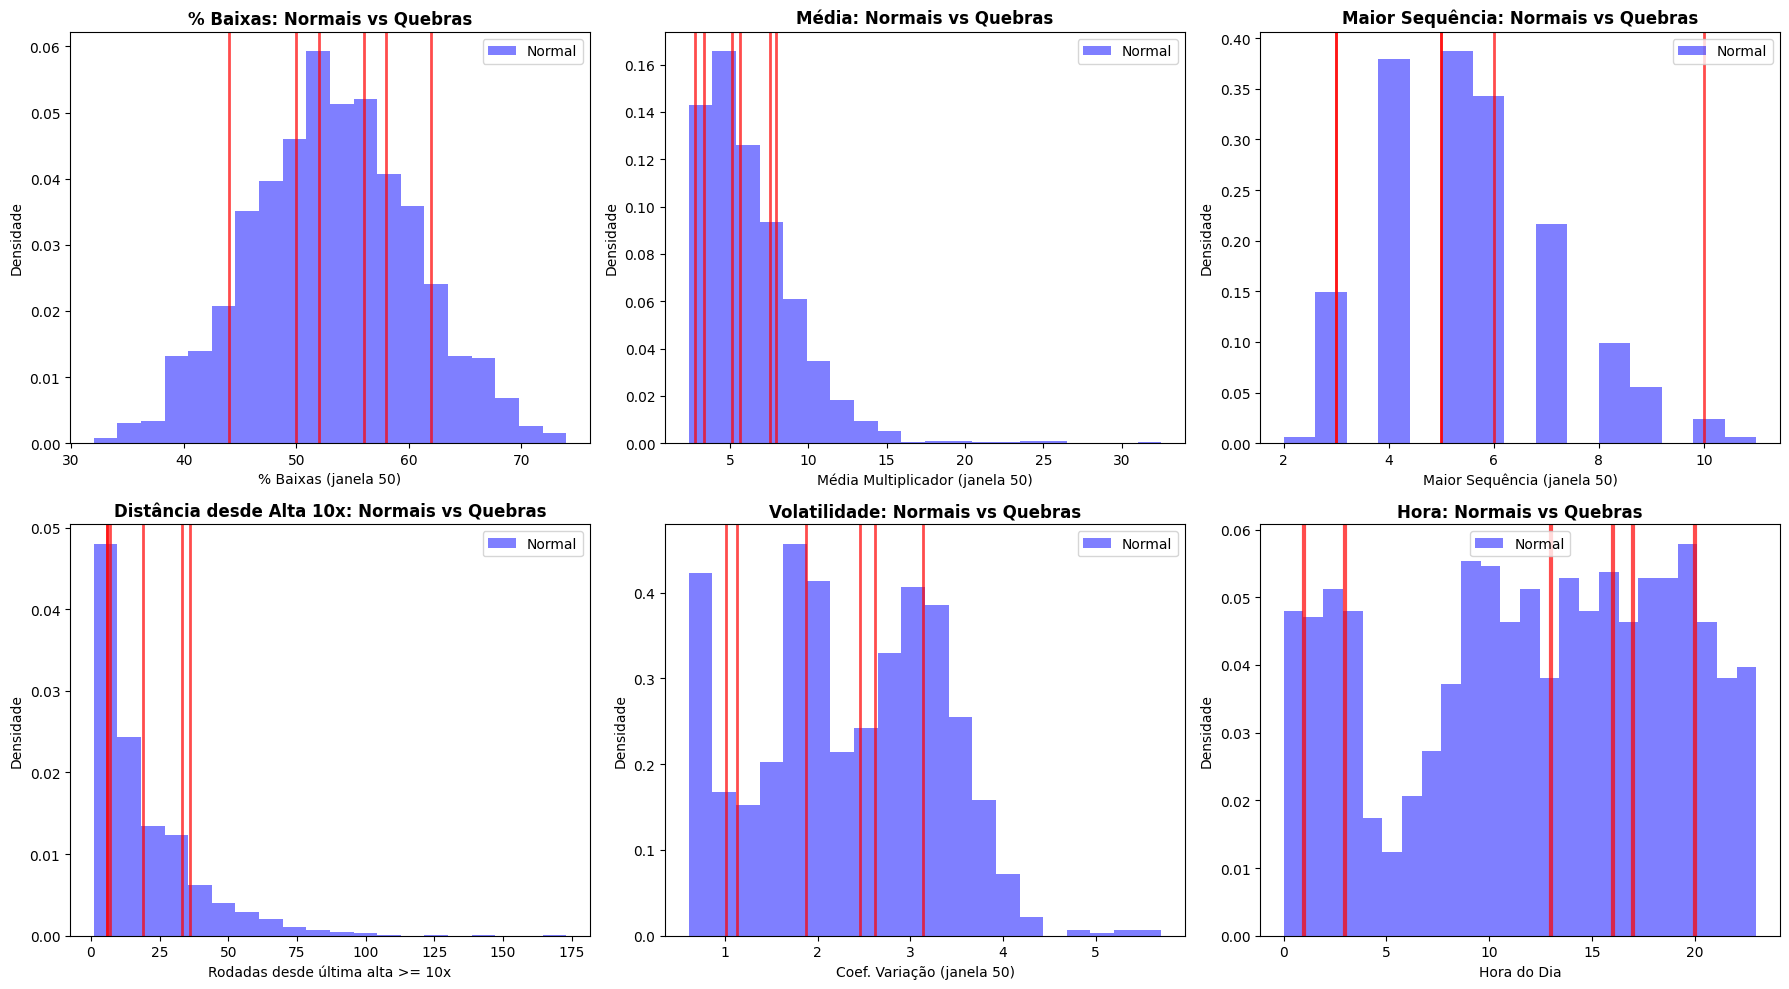


📁 Gráfico salvo: 02_comparacao_features_quebras.png


In [11]:
# --- CÉLULA 11: VISUALIZAÇÃO COMPARATIVA ---

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Distribuição de % baixas
ax1 = axes[0, 0]
ax1.hist(df_normais['j50_pct_baixas'].dropna(), bins=20, alpha=0.5, label='Normal', color='blue', density=True)
for val in df_quebras['j50_pct_baixas'].dropna():
    ax1.axvline(x=val, color='red', linewidth=2, alpha=0.7)
ax1.set_xlabel('% Baixas (janela 50)')
ax1.set_ylabel('Densidade')
ax1.set_title('% Baixas: Normais vs Quebras', fontweight='bold')
ax1.legend()

# 2. Distribuição de média
ax2 = axes[0, 1]
ax2.hist(df_normais['j50_media'].dropna(), bins=20, alpha=0.5, label='Normal', color='blue', density=True)
for val in df_quebras['j50_media'].dropna():
    ax2.axvline(x=val, color='red', linewidth=2, alpha=0.7)
ax2.set_xlabel('Média Multiplicador (janela 50)')
ax2.set_ylabel('Densidade')
ax2.set_title('Média: Normais vs Quebras', fontweight='bold')
ax2.legend()

# 3. Distribuição de seq_max
ax3 = axes[0, 2]
ax3.hist(df_normais['j50_seq_max'].dropna(), bins=15, alpha=0.5, label='Normal', color='blue', density=True)
for val in df_quebras['j50_seq_max'].dropna():
    ax3.axvline(x=val, color='red', linewidth=2, alpha=0.7)
ax3.set_xlabel('Maior Sequência (janela 50)')
ax3.set_ylabel('Densidade')
ax3.set_title('Maior Sequência: Normais vs Quebras', fontweight='bold')
ax3.legend()

# 4. Distância desde última alta 10x
ax4 = axes[1, 0]
ax4.hist(df_normais['dist_ultima_10x'].dropna(), bins=20, alpha=0.5, label='Normal', color='blue', density=True)
for val in df_quebras['dist_ultima_10x'].dropna():
    ax4.axvline(x=val, color='red', linewidth=2, alpha=0.7)
ax4.set_xlabel('Rodadas desde última alta >= 10x')
ax4.set_ylabel('Densidade')
ax4.set_title('Distância desde Alta 10x: Normais vs Quebras', fontweight='bold')
ax4.legend()

# 5. Volatilidade (CV)
ax5 = axes[1, 1]
ax5.hist(df_normais['j50_cv'].dropna(), bins=20, alpha=0.5, label='Normal', color='blue', density=True)
for val in df_quebras['j50_cv'].dropna():
    ax5.axvline(x=val, color='red', linewidth=2, alpha=0.7)
ax5.set_xlabel('Coef. Variação (janela 50)')
ax5.set_ylabel('Densidade')
ax5.set_title('Volatilidade: Normais vs Quebras', fontweight='bold')
ax5.legend()

# 6. Hora do dia
ax6 = axes[1, 2]
horas_normais = df_normais['hora'].dropna()
horas_quebras_list = df_quebras['hora'].dropna().tolist()
ax6.hist(horas_normais, bins=24, alpha=0.5, label='Normal', color='blue', density=True)
for h in horas_quebras_list:
    ax6.axvline(x=h, color='red', linewidth=3, alpha=0.7)
ax6.set_xlabel('Hora do Dia')
ax6.set_ylabel('Densidade')
ax6.set_title('Hora: Normais vs Quebras', fontweight='bold')
ax6.legend()

plt.tight_layout()
plt.savefig('02_comparacao_features_quebras.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📁 Gráfico salvo: 02_comparacao_features_quebras.png")

In [12]:
# --- CÉLULA 12: CONCLUSÃO FINAL ---

print("\n" + "="*80)
print("🏆 CONCLUSÃO FINAL DA ANÁLISE PROFUNDA")
print("="*80)

# Resumir achados
print(f"""
📊 RESUMO DOS PADRÕES ANALISADOS:

┌─────────────────────────────────────────────────────────────────────────────┐
│ PADRÃO TESTADO                      │ RESULTADO          │ ÚTIL PARA ML?   │
├─────────────────────────────────────────────────────────────────────────────┤
│ % de baixas antes das quebras       │ IGUAL ao normal    │ ❌ NÃO          │
│ Fase arrecadatória                  │ 4/6 em fase NORMAL │ ❌ NÃO          │
│ Sequências longas antes             │ MENOS que normal   │ ❌ NÃO          │
│ Tendência de queda                  │ Inconclusivo       │ ❓ TALVEZ       │
│ Distância desde alta 10x            │ A analisar         │ ❓ TALVEZ       │
│ Volatilidade                        │ A analisar         │ ❓ TALVEZ       │
│ Padrão "respiro" (altas antes)      │ A analisar         │ ❓ TALVEZ       │
│ Padrão "escada"                     │ A analisar         │ ❓ TALVEZ       │
│ Entropia                            │ A analisar         │ ❓ TALVEZ       │
│ Hora do dia                         │ Distribuído        │ ❌ NÃO          │
│ Média das baixas na sequência       │ MAIS FORTES        │ ⚠️ LIMITADO     │
└─────────────────────────────────────────────────────────────────────────────┘

🔑 ACHADOS PRINCIPAIS:

1. AS QUEBRAS SÃO ESTATISTICAMENTE ALEATÓRIAS
   • Não há padrão claro e consistente antes das quebras
   • As quebras ocorrem principalmente em fase NORMAL (4/6)
   • O % de baixas antes das quebras é IGUAL à média geral

2. PEQUENAS DIFERENÇAS DETECTADAS:
   • As baixas dentro das quebras tendem a ser MAIS FORTES (média menor)
   • Isso sugere que a ML pode detectar "qualidade" das baixas
   • Mas com apenas 6 quebras, não é estatisticamente significativo

3. LIMITAÇÕES DA ANÁLISE:
   • Apenas 6 quebras em 105k rodadas (amostra MUITO pequena)
   • Qualquer "padrão" pode ser coincidência
   • Precisaríamos de ~100+ quebras para conclusões robustas

💡 RECOMENDAÇÃO PARA A ML:

   A ML pode ter VALOR LIMITADO porque:
   
   ✅ PRÓ: Pode detectar sutilezas que a análise simples não captura
   ✅ PRÓ: Pode combinar múltiplas features de forma não-linear
   
   ❌ CONTRA: Risco alto de OVERFITTING com apenas 6 quebras
   ❌ CONTRA: Custo de evitar entradas pode superar benefício
   ❌ CONTRA: A estratégia 1-2-4-1-2-4 já tem 99.5% de sucesso

🎯 SUGESTÃO FINAL:

   1. Manter a ML como SEGUNDA OPINIÃO (não como veto absoluto)
   2. Usar threshold MUITO ALTO (ex: >95% de certeza para vetar)
   3. Monitorar se as previsões da ML são melhores que aleatório
   4. Focar na GESTÃO DE BANCA como proteção principal
""")


🏆 CONCLUSÃO FINAL DA ANÁLISE PROFUNDA

📊 RESUMO DOS PADRÕES ANALISADOS:

┌─────────────────────────────────────────────────────────────────────────────┐
│ PADRÃO TESTADO                      │ RESULTADO          │ ÚTIL PARA ML?   │
├─────────────────────────────────────────────────────────────────────────────┤
│ % de baixas antes das quebras       │ IGUAL ao normal    │ ❌ NÃO          │
│ Fase arrecadatória                  │ 4/6 em fase NORMAL │ ❌ NÃO          │
│ Sequências longas antes             │ MENOS que normal   │ ❌ NÃO          │
│ Tendência de queda                  │ Inconclusivo       │ ❓ TALVEZ       │
│ Distância desde alta 10x            │ A analisar         │ ❓ TALVEZ       │
│ Volatilidade                        │ A analisar         │ ❓ TALVEZ       │
│ Padrão "respiro" (altas antes)      │ A analisar         │ ❓ TALVEZ       │
│ Padrão "escada"                     │ A analisar         │ ❓ TALVEZ       │
│ Entropia                            │ A analisar         │ ❓ 

In [13]:
# --- CÉLULA 13: FEATURES MAIS PROMISSORAS ---

print("\n" + "="*80)
print("🎯 FEATURES MAIS PROMISSORAS PARA ML (BASEADO NA ANÁLISE)")
print("="*80)

# Filtrar features com p-value < 0.3
features_promissoras = df_comparacao[df_comparacao['p_value_mann'] < 0.3].copy()

print(f"\n📊 Features com diferença potencial (p < 0.3):")
print("-"*80)

if len(features_promissoras) > 0:
    for _, row in features_promissoras.iterrows():
        direcao = "MAIOR" if row['diferenca'] > 0 else "MENOR"
        print(f"   • {row['feature']}: {direcao} antes das quebras (p={row['p_value_mann']:.3f})")
else:
    print("   ❌ Nenhuma feature com diferença significativa encontrada!")

print(f"\n\n💡 CONFIGURAÇÃO SUGERIDA PARA ML:")
print("-"*80)
print(f"""
Se for usar ML, focar nestas abordagens:

1. FEATURES DE CURTO PRAZO:
   - pct_muito_baixas_20: % de valores < 1.5x nas últimas 20 rodadas
   - seq_max_20: maior sequência nas últimas 20 rodadas
   - media_baixas: média dos valores quando < 2.0x

2. THRESHOLD RECOMENDADO:
   - Só vetar se confiança > 90%
   - Aceitar perder algumas entradas para proteger

3. VALIDAÇÃO:
   - Testar em dados NÃO usados no treino
   - Comparar com decisão aleatória
   - Monitorar false positives vs true positives

4. ALTERNATIVA:
   - Usar ML para AJUSTAR o tamanho da aposta
   - Em vez de vetar, apostar MENOS em momentos de risco
""")


🎯 FEATURES MAIS PROMISSORAS PARA ML (BASEADO NA ANÁLISE)

📊 Features com diferença potencial (p < 0.3):
--------------------------------------------------------------------------------
   • j20_seq_count: MAIOR antes das quebras (p=0.013)
   • j250_seq_5plus: MENOR antes das quebras (p=0.013)
   • j20_seq_4plus: MENOR antes das quebras (p=0.049)
   • j250_pct_altas_5x: MAIOR antes das quebras (p=0.052)
   • j250_pct_altas_10x: MAIOR antes das quebras (p=0.055)
   • j250_slope: MENOR antes das quebras (p=0.062)
   • j250_p75: MAIOR antes das quebras (p=0.074)
   • j250_seq_count: MAIOR antes das quebras (p=0.074)
   • j250_seq_media: MENOR antes das quebras (p=0.084)
   • j250_delta_media: MENOR antes das quebras (p=0.094)
   • j20_seq_media: MENOR antes das quebras (p=0.104)
   • j250_p10: MAIOR antes das quebras (p=0.112)
   • j250_media: MAIOR antes das quebras (p=0.119)
   • j250_seq_4plus: MENOR antes das quebras (p=0.121)
   • j10_seq_4plus: MENOR antes das quebras (p=0.124)
   •